<a href="https://colab.research.google.com/github/sanoukoudouss2-tech/Gestion-de-portefeuille-selon-Markowitz/blob/main/r%C3%A9seaux_de_neurones_chien_chat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from utilities import *
import matplotlib.pyplot as plt
from fonctions import *

In [ ]:
X_train,y_train,X_test,y_test = load_data()

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train,return_counts=True))

(1000, 64, 64)
(1000, 1)
(array([0., 1.]), array([500, 500]))


In [ ]:
print(X_test.shape)
print(y_test.shape)
print(np.unique(y_test,return_counts=True))

(200, 64, 64)
(200, 1)
(array([0., 1.]), array([100, 100]))


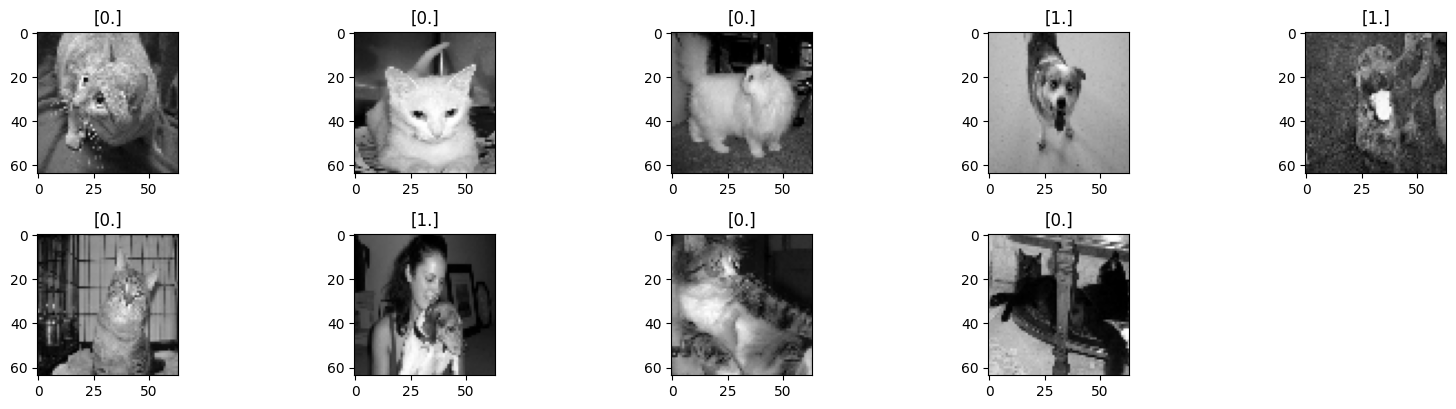

In [ ]:
plt.figure(figsize=(16,8))
for i in range(1,10):
    plt.subplot(4,5,i)
    plt.imshow(X_train[i],cmap='grey')
    plt.title(y_train[i])
    plt.tight_layout()
plt.show()

In [ ]:
## je convertis mes images en vecteurs

X_train = X_train.reshape(4096,1000)
X_test = X_test.reshape(4096,200)
y_train = y_train.T
y_test = y_test.T

In [ ]:
## je les normalise
xmin = X_train.min()
xmax = X_train.max()
X_train = (X_train - xmin)/(xmax - xmin)
X_test = (X_test - xmin)/(xmax - xmin)

100%|██████████| 2000/2000 [00:34<00:00, 57.76it/s]


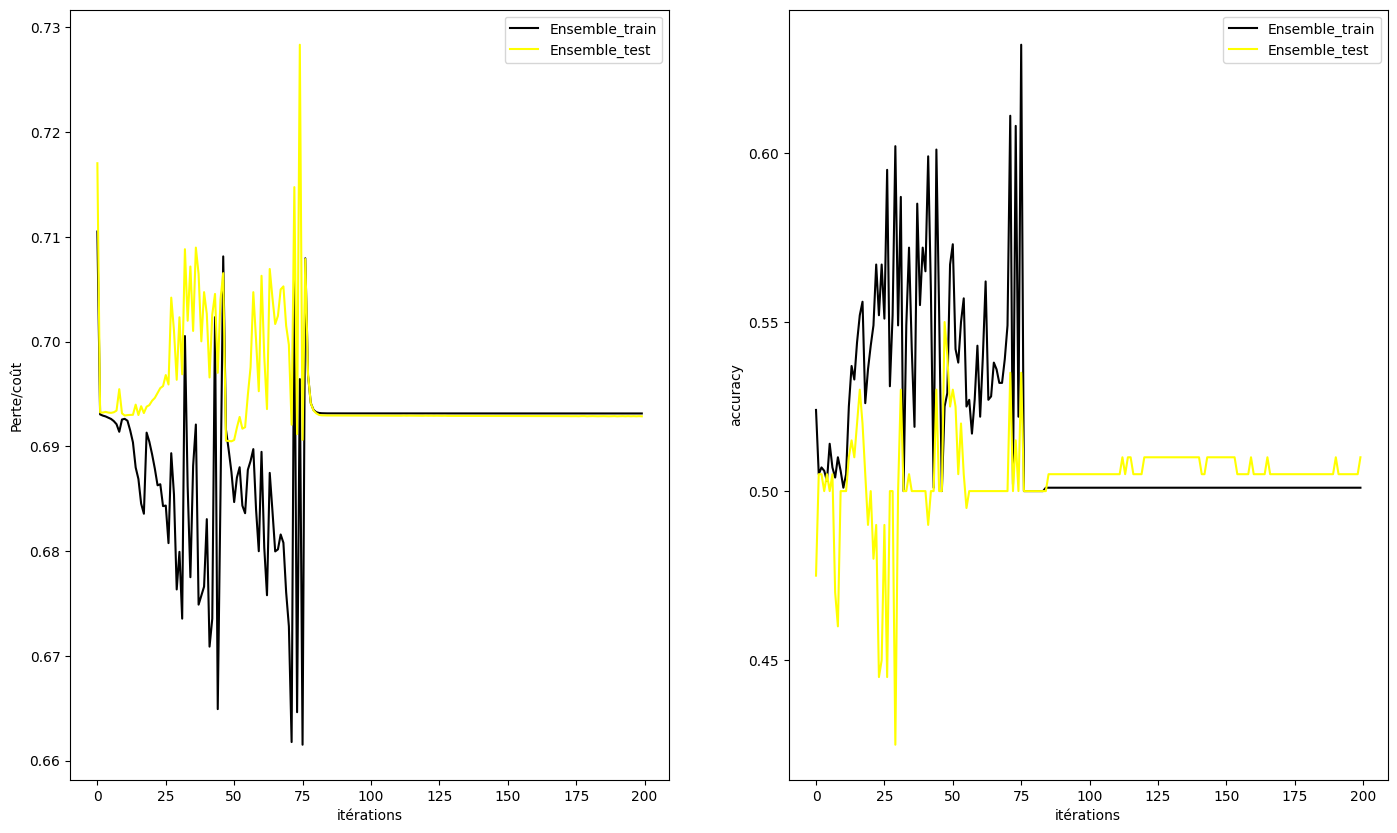

In [ ]:
## Application
parametres = fit(X_train,X_test,y_train,y_test,32,32,0.1,2000)

100%|██████████| 2000/2000 [00:26<00:00, 75.41it/s] 


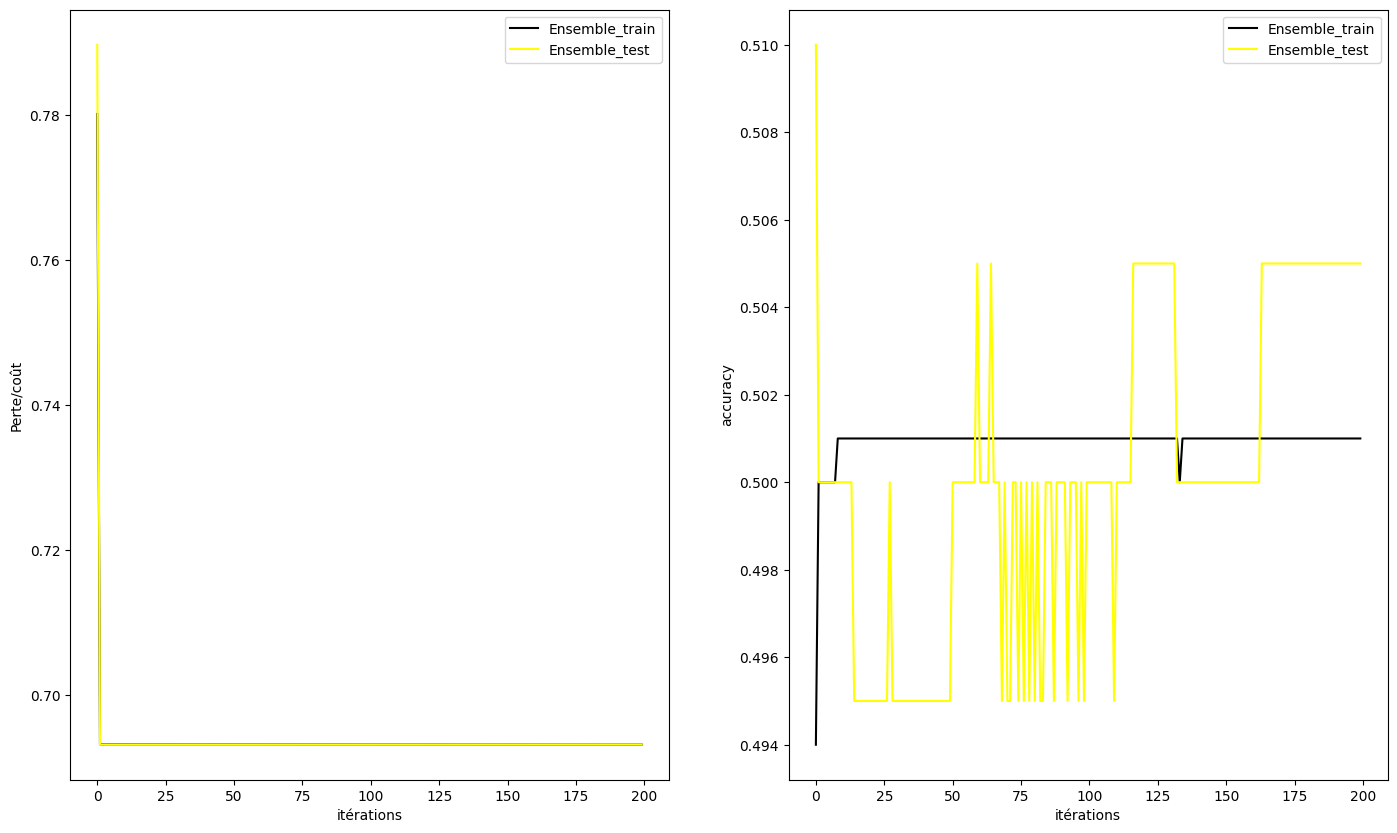

In [ ]:
par1 = fit(X_train,X_test,y_train,y_test,16,16,0.1,2000)

100%|██████████| 100/100 [00:01<00:00, 89.46it/s]


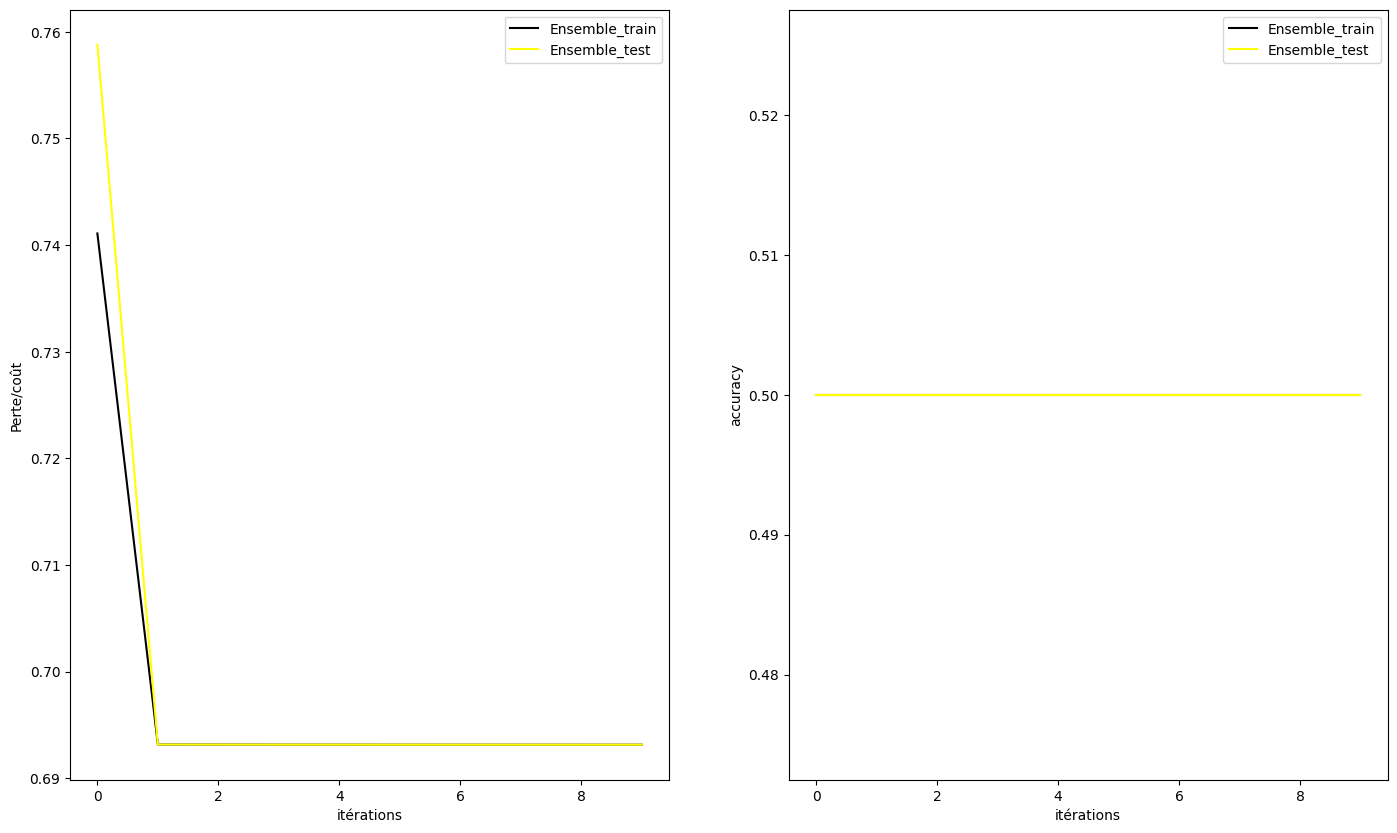

In [ ]:
par2 = fit(X_train,X_test,y_train,y_test,4,4,0.1,100)


100%|██████████| 500/500 [00:15<00:00, 32.07it/s]


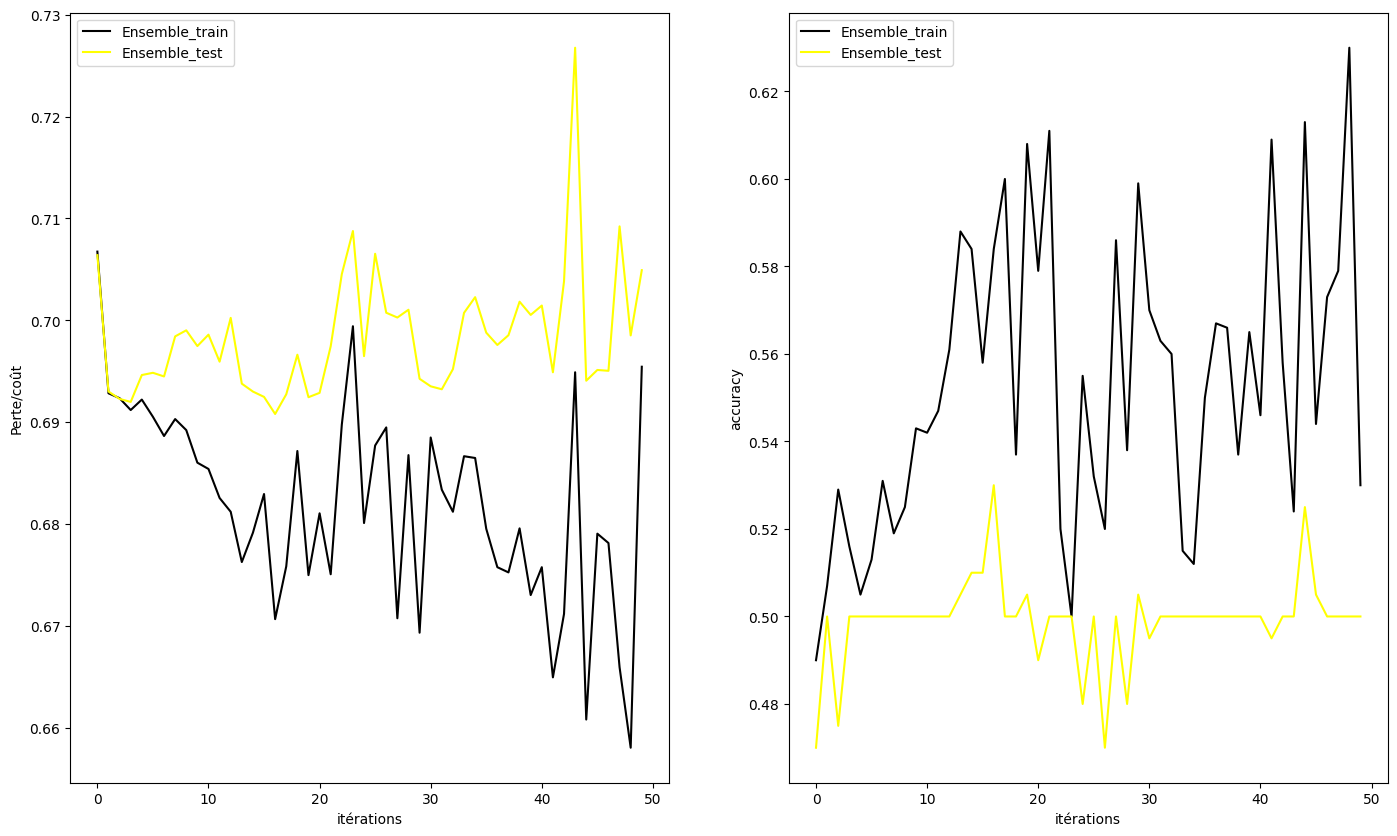

In [ ]:
par3 = fit(X_train,X_test,y_train,y_test,64,64,0.1,500)

100%|██████████| 500/500 [00:26<00:00, 18.58it/s]


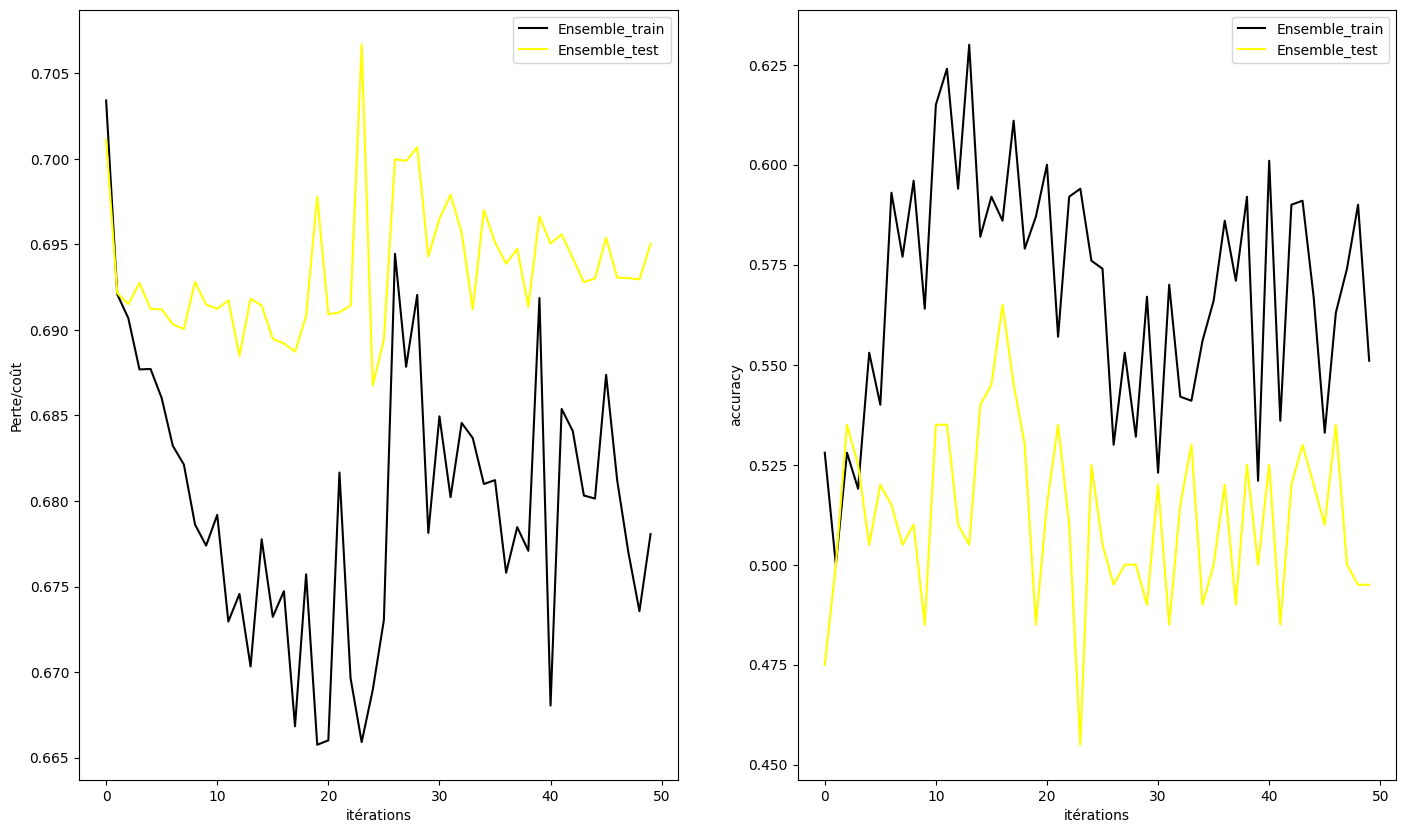

In [ ]:
par4 = fit(X_train,X_test,y_train,y_test,120,120,0.1,500)

100%|██████████| 500/500 [04:07<00:00,  2.02it/s]


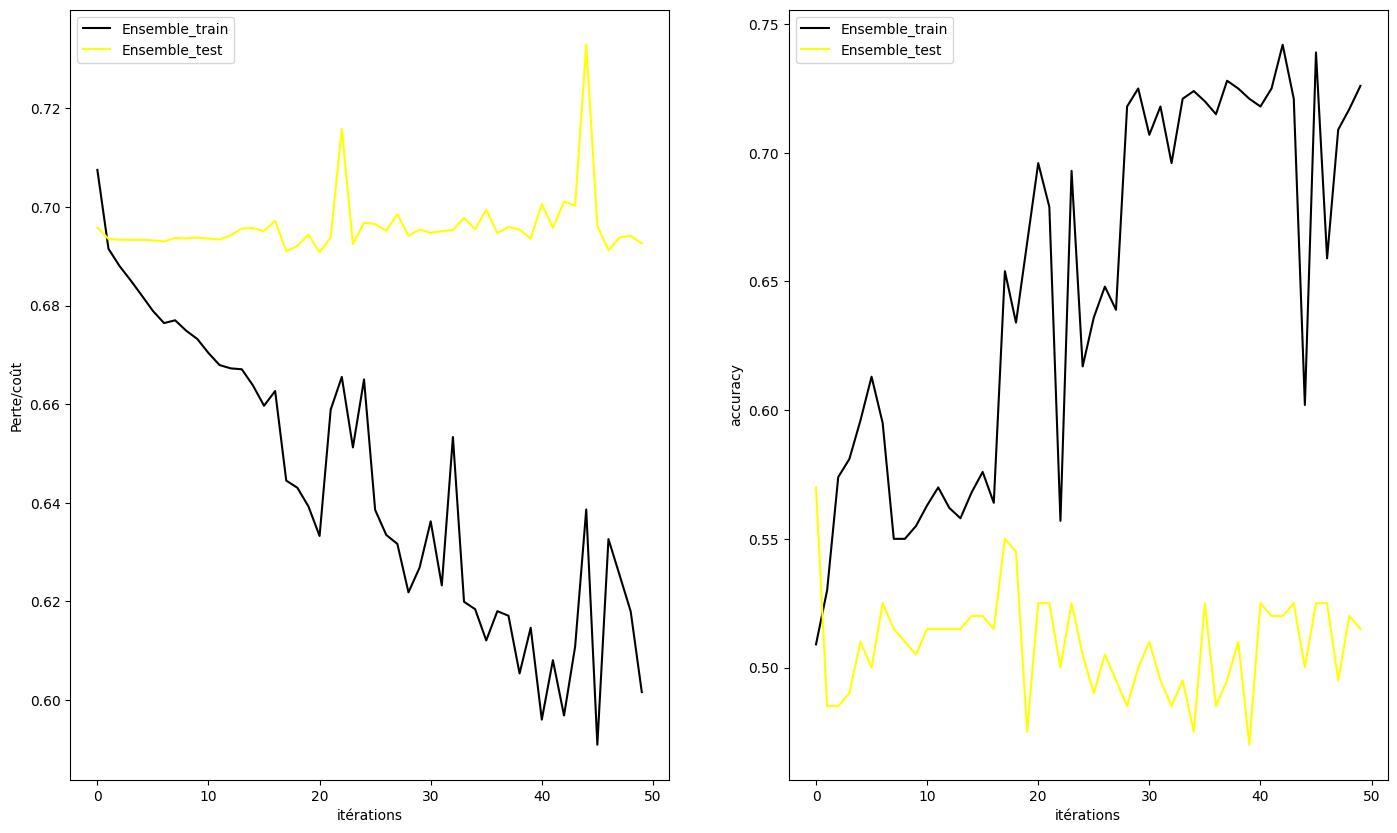

In [ ]:
par5 = fit(X_train,X_test,y_train,y_test,1000,1000,0.1,500)

100%|██████████| 10000/10000 [02:05<00:00, 79.99it/s]


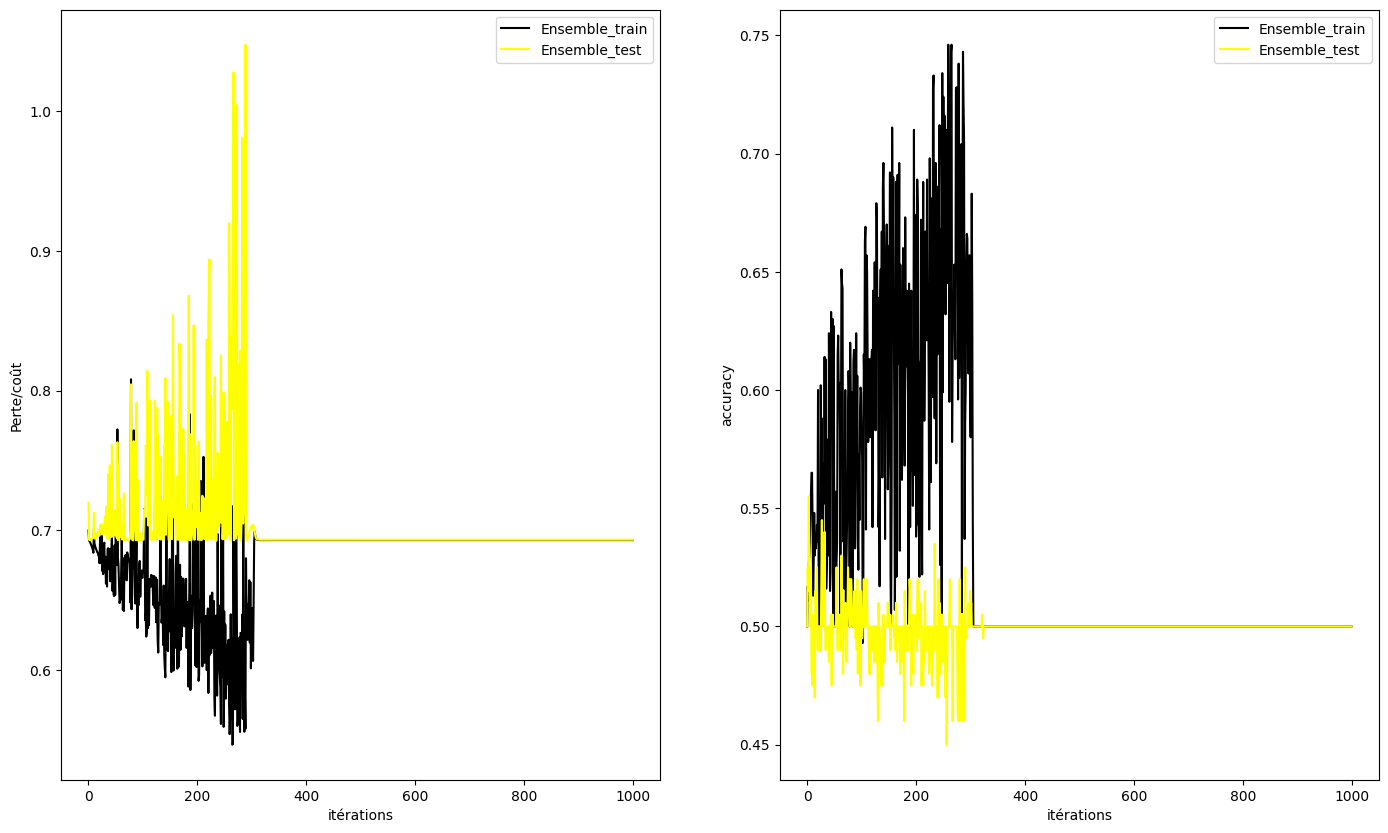

In [ ]:
par6 = fit(X_train,X_test,y_train,y_test,8,8,0.1,10000)

100%|██████████| 500/500 [00:14<00:00, 33.59it/s]


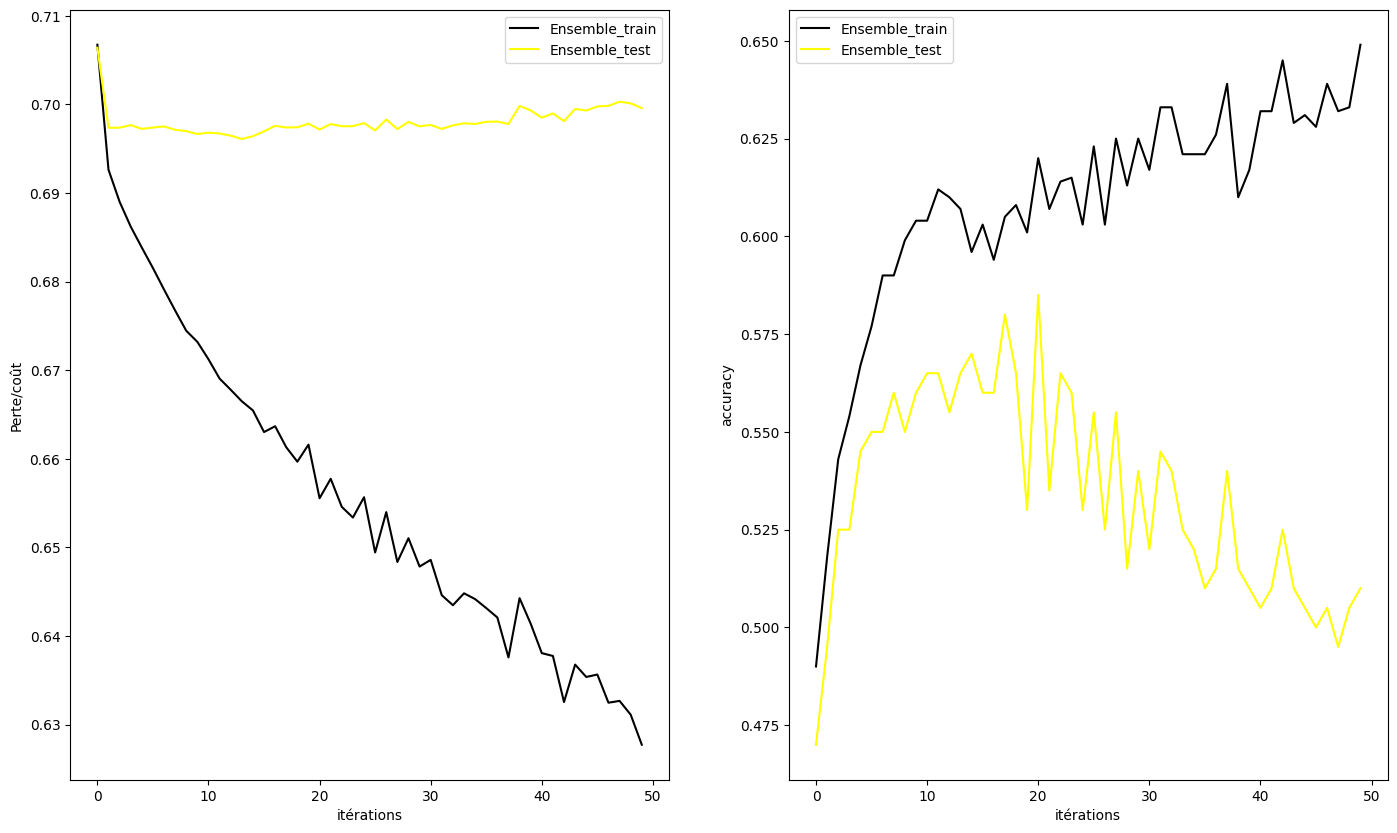

In [ ]:
par7 = fit(X_train,X_test,y_train,y_test,64,64,0.01,500)

100%|██████████| 10000/10000 [05:17<00:00, 31.48it/s]


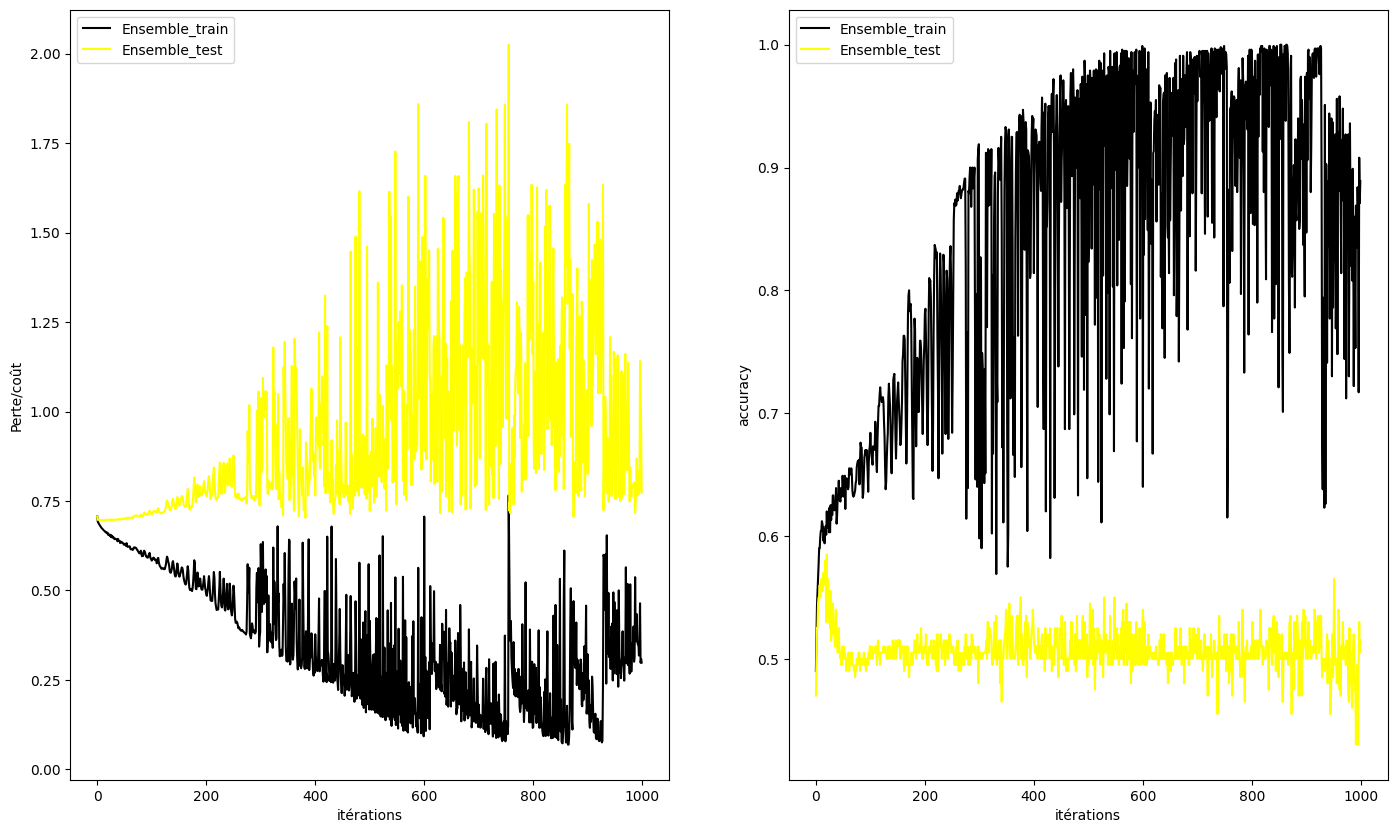

In [ ]:
par8 = fit(X_train,X_test,y_train,y_test,64,64,0.01,10000)

In [33]:
from tensorflow.keras import layers,models
import tensorflow as tf

In [34]:
import h5py
import numpy as np


def load_data():
    train_dataset = h5py.File('datasets/trainset.hdf5', "r")
    X_train = np.array(train_dataset["X_train"][:]) # your train set features
    y_train = np.array(train_dataset["Y_train"][:]) # your train set labels

    test_dataset = h5py.File('datasets/testset.hdf5', "r")
    X_test = np.array(test_dataset["X_test"][:]) # your train set features
    y_test = np.array(test_dataset["Y_test"][:]) # your train set labels

    return X_train, y_train, X_test, y_test

In [35]:
from google.colab import drive
import os

# 1. Connecter le Google Drive
drive.mount('/content/drive')

# 2. Se déplacer dans le dossier où se trouvent vos datasets (à adapter selon votre structure)
# Exemple si votre dossier 'datasets' est à la racine de votre Google Drive :
os.chdir('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
## On initialise un modele séquentiel couche apres couche
model = models.Sequential()

In [37]:
## couche 1: convolution(32filtres de taille 3x3) + activativation + Pooling
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(64,64,1)))## input represente la dimension de l'image d'entrée
model.add(layers.MaxPooling2D((2,2)))

In [38]:
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [39]:
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [40]:
## Couche 2, applatir la matrice pour la transformer en vecteur
model.add(layers.Flatten())

In [46]:
## Couche 3, couche dense classique (MLP) pour la classification finale
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dropout(0.5))

In [47]:
model.add(layers.Dense(1,activation="sigmoid"))

In [48]:
## L'entrainemet
model.compile(optimizer='adam',## optimizer represente l'algorithme utilisé pour mettre a jour les poids, par ex descente de gradient, ect
              loss = 'binary_crossentropy', ## la fonction qui calcule le score ou l'erreur
              metrics = ['accuracy'])## Permet a l'humain de voir l'exactitude de ces résultats

Mounted at /content/drive


In [43]:
X_train,y_train,X_test,y_test = load_data()
## je les normalise
xmin = X_train.min()
xmax = X_train.max()
X_train = (X_train - xmin)/(xmax - xmin)
X_test = (X_test - xmin)/(xmax - xmin)

In [44]:
X_train.shape

(1000, 64, 64)

In [49]:
# 2. CORRECTION : Ajouter la dimension du canal (devient 1000, 64, 64, 1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# 3. CORRECTION : Entraîner en incluant y_train et y_test
history = model.fit(
    X_train,
    y_train,                     # <-- Ajout des étiquettes d'entraînement
    validation_data=(X_test, y_test),  # <-- Ajout du tuple (X, y) pour la validation
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.5220 - loss: 0.7515 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.4710 - loss: 0.7135 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.5030 - loss: 0.7028 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.5180 - loss: 0.6969 - val_accuracy: 0.5400 - val_loss: 0.6917
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.5140 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6971
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.5100 - loss: 0.6998 - val_accuracy: 0.6000 - val_loss: 0.6895
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.5020 - loss: 0.7023 - val_accuracy: 0.5600 - val_loss: 0.6900
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.5300 - loss: 0.6898 - val_accuracy: 

In [50]:
from sklearn.linear_model import LogisticRegression
X_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
clf = LogisticRegression(max_iter=1000).fit(X_flat, y_train.ravel())
print(clf.score(X_test_flat, y_test.ravel()))

0.565
